# Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

## 1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 118,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

## 2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. Specifically, we investigate:
- What is the primary driver of dropout: academic preparedness, current performance, or financial constraints?
- How do financial factors interact with academic factors to influence dropout risk?
- Does the impact vary significantly by demographics, programme of study, or engagement levels?
- Can a predictive model identify students at high risk of dropping out early?

## 3. Objectives
1. **Descriptive Analysis** — Profile the student population and compare characteristics of dropouts vs. persisters.
2. **Exploratory Analysis** — Investigate relationships between independent variables and dropout status.
3. **Predictive Modelling** — Develop and evaluate a stacking classifier to predict dropout risk.
4. **Actionable Insights** — Translate findings into recommendations for administrators and policymakers.

## 1. Library Imports

All required libraries are imported here. The stack covers:
- **Data wrangling:** `pandas`, `numpy`, `datetime`
- **Visualisation:** `matplotlib`, `seaborn`
- **Statistics:** `scipy.stats` for Chi-square and t-tests
- **Preprocessing:** `sklearn` scalers and encoders
- **Models:** Logistic Regression, Random Forest, XGBoost, Balanced Random Forest, Gradient Boosting, and a Stacking Ensemble
- **Evaluation:** A comprehensive set of classification metrics

> **Note:** Run `!pip install imblearn xgboost` if those packages are not yet installed in your environment.

## 1. Imports

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import fbeta_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score,
    roc_curve, auc, precision_recall_curve, precision_score)

# Pipeline
from sklearn.pipeline import Pipeline

# Warnings
import warnings
warnings.filterwarnings('ignore')

import pickle
import os

## 2. Data Loading

The raw dataset (`student.csv`) contains records for **118,000+ students** from Kenyan higher education institutions. Each row represents one student and includes demographic, financial, academic, and institutional attributes.

We begin by loading the file into a DataFrame and performing an initial inspection to understand its shape, column types, and the extent of missing values.

## 2. Data Loading

In [2]:
School_df = pd.read_csv("student.csv")
School_df.head()

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0


### 2.1 Dataset Dimensions & Column Types

`.shape` gives us the total number of rows and columns. `.info()` reveals each column's data type and the count of non-null values — a quick way to spot columns with substantial missing data before a full null audit.

In [3]:
print(School_df.shape)
School_df.info()

(118259, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  

### 2.2 Missing Value Audit

Counting nulls column-by-column helps us decide which columns to drop outright versus which rows to filter when a small number of key fields are absent.

In [4]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

## 3. Data Cleaning

Raw administrative data frequently contains administrative artefacts (batch numbers, index codes), rows with missing values in key analytical fields, unsupported categorical codes, and duplicate records. This section addresses all four issues systematically before any analysis begins.

### 3.1 Drop Irrelevant Columns

The following columns are removed because they are either administrative identifiers (e.g., `Adm No`, `INDEXNUMBER`) that add no predictive value, or they contain data that is redundant, entirely empty, or otherwise unsuitable for modelling:

| Column | Reason for Removal |
|---|---|
| `BURSARYBATCHNUMBER` | Internal admin batch reference |
| `Unnamed: 21` | Phantom column from CSV export |
| `PHYSICALLYCHALLENGED` | Predominantly null; cannot be reliably used |
| `Loan_serial_number` | Unique per loan — not a feature |
| `InstitutionCode` | Superseded by `UniversityType` |
| `Adm No` / `INDEXNUMBER` | Student ID — leaks identity, not a predictor |
| `COURSECODE` | Superseded by `CourseCategory` |
| `BursaryAllocated` | Redundant with loan allocation fields |
| `applicanttype` | Insufficient variation to be informative |

### 3.1 Drop Irrelevant Columns

In [5]:
columns_to_drop = [
    'BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED',
    'Loan_serial_number', 'InstitutionCode', 'Adm No',
    'COURSECODE', 'INDEXNUMBER', 'BursaryAllocated', 'applicanttype'
]
School_df = School_df.drop(columns=columns_to_drop, errors='ignore')
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='object')

### 3.2 Drop Rows with Missing Values in Key Columns

Rows are removed only when a **core analytical field** is null. These eight fields are required for either the EDA or the model; imputation would introduce noise given the volume of data available.

### 3.2 Drop Rows with Missing Values in Key Columns

In [6]:
School_df = School_df.dropna(subset=[
    "Gender", "County", "ProgramCost", "CourseCategory",
    "Father_educ_level", "Mother_educ_level", "LoanStatus", "Highest_educ_level"
])
School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

### 3.3 Remove Unsupported Loan Product Codes

Two loan product codes — `DL6` and `VC` — represent pilot or discontinued schemes with very few records. Retaining them would create near-empty categories that distort aggregations and confuse the model.

### 3.3 Remove Unsupported Loan Product Codes

In [7]:
School_df = School_df[
    ~School_df['LoanproductCode'].isin(['DL6', 'VC'])
]
School_df['LoanproductCode'].value_counts()

UG    47652
Name: LoanproductCode, dtype: int64

### 3.4 Remove Duplicate Records

Exact duplicates (same values across every column) are dropped. A before/after count confirms how many redundant rows were removed.

### 3.4 Remove Duplicates

In [8]:
print("Duplicates before:", School_df.duplicated().sum())
School_df = School_df.drop_duplicates()
print("Duplicates after:", School_df.duplicated().sum())

Duplicates before: 6
Duplicates after: 0


## 4. Feature Engineering

Raw columns are transformed into richer features that better capture the underlying phenomena:
- **Age** is derived from `Birthdate` to give a continuous numeric signal.
- **University Type** and **Sponsorship** are parsed out of the composite `Category` string.
- **Age groups** bin the continuous age variable for stratified EDA.

The cleaned and enriched dataset is then exported for reproducibility.

### Assumptions
- Age 16+ is eligible to join an undergraduate programme.

### 4.1 Derive Student Age from Birthdate

Age is calculated as the difference between today's date and `Birthdate`, accounting for whether the student's birthday has already occurred this year. Invalid or missing birth dates yield `None` and are handled downstream.

### 4.1 Create Age Column

In [9]:
# Convert Birthdate to datetime and derive age
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")
today = datetime.today()
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

### 4.2 Parse University Type & Sponsorship

The `Category` column encodes two attributes in a single string (e.g., `"Public – GovtSponsored"`). A regex extraction splits this into:
- **`UniversityType`** — `Public` or `Private`
- **`Sponsored`** — `GovtSponsored` or `SelfSponsored`

These two binary dimensions are highly relevant to both financial burden and dropout risk.

### 4.2 Extract University Type and Sponsorship from Category

In [10]:
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df[['UniversityType', 'Sponsored']].value_counts()

UniversityType  Sponsored    
Public          GovtSponsored    41972
Private         SelfSponsored     3699
Public          SelfSponsored     1132
Private         GovtSponsored      843
dtype: int64

### 4.3 Create Age Group Bins

The continuous `age` column is bucketed into three ordinal groups for EDA-level comparisons. The bins are chosen to reflect common student cohort boundaries in Kenyan higher education:
- **`<17`** — below typical undergraduate entry age (edge cases)
- **`18–21`** — mainstream school-leaver cohort
- **`22–25`** — slightly older entrants or returners

### 4.3 Create Age Groups

In [11]:
bins   = [0, 18, 21, 25]
labels = ['<17', '18-21', '22-25']
School_df['age_group'] = pd.cut(School_df['age'], bins=bins, labels=labels)
School_df['age_group'].value_counts()

18-21    35157
<17       6313
22-25     5529
Name: age_group, dtype: int64

### 4.4 Persist the Cleaned & Engineered Dataset

The enriched DataFrame is written to `cleaned.csv` so that downstream notebooks or collaborators can pick up from a reproducible checkpoint without re-running the cleaning pipeline.

### 4.4 Export Cleaned Dataset

In [12]:
School_df.to_csv('cleaned.csv', index=False)
print(f"Cleaned dataset saved: {School_df.shape[0]} rows, {School_df.shape[1]} columns")

Cleaned dataset saved: 47646 rows, 22 columns


## 5. Exploratory Data Analysis (EDA)

This section visualises the key relationships in the data before modelling. The goals are to:
1. Understand the distribution of individual variables.
2. Identify which demographic, financial, and institutional factors co-vary with dropout status.
3. Surface any data quality issues that may have survived cleaning (e.g., extreme outliers).

> **Note on scope:** After EDA reveals that the data span multiple exam years with differing dropout rates, the analysis is narrowed to **ExamYear = 2024** to ensure temporal consistency in the modelling dataset.

### 5.1 Age Distribution

A box plot of the raw `age` column reveals the central tendency and the presence of extreme outliers (e.g., implausible ages from erroneous birth dates). Records outside the plausible student age window (16–25) are subsequently filtered to prevent these outliers from skewing downstream analyses.

### 5.1 Age Distribution

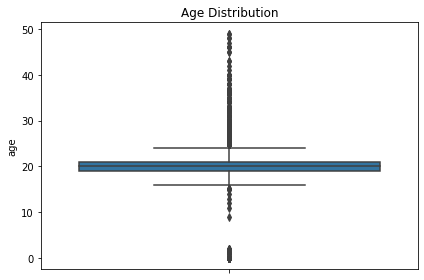

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=School_df['age'])
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

#### Filter to Valid Student Age Range

Students younger than 16 or older than 25 are removed. The 16–25 window covers virtually all conventional undergraduate students while excluding data-entry errors (e.g., birth years entered as exam years).

In [14]:
# Filter to valid student age range to deal with
School_df = School_df[School_df['age'] >= 17]
School_df = School_df[(School_df['age'] >= 16) & (School_df['age'] <= 25)]
School_df['age'].describe()

count    46884.000000
mean        19.822199
std          1.393427
min         17.000000
25%         19.000000
50%         20.000000
75%         21.000000
max         25.000000
Name: age, dtype: float64

#### Age Frequency Table

Check the per-age count after filtering to confirm the distribution is reasonable.

In [15]:
School_df.age.value_counts()

19.0    16176
20.0    12435
21.0     6546
18.0     5494
22.0     3276
23.0     1428
17.0      704
24.0      567
25.0      258
Name: age, dtype: int64

### 5.2 Dropout Rate by County

Kenya's 47 counties differ in socioeconomic conditions, distance from institutions, and access to bursary support. This section:
1. **Standardises** county name strings (case, punctuation, known misspellings).
2. **Aggregates** total students and dropouts per county.
3. **Visualises** the per-county dropout percentage ranked from highest to lowest, with a national average reference line.

### 5.2 School Drop Out Rate by County in Kenya

In [16]:
# 1. Standardize to uppercase and strip whitespace
School_df['County'] = School_df['County'].astype(str).str.upper().str.strip()

# 2. Cleanup punctuation and spacing
# We replace slashes and hyphens with spaces, but we'll handle the apostrophe carefully
School_df['County'] = School_df['County'].str.replace(r'[-/]', ' ', regex=True)
School_df['County'] = School_df['County'].str.replace(r'\s+', ' ', regex=True)

# 3. Specific fix for Murang'a and other duplicates
mapping = {
    'MURANG A': "MURANG'A",
    'MURANGA': "MURANG'A",
    'TRANSNZOIA': 'TRANS NZOIA'
}

School_df['County'] = School_df['County'].replace(mapping)

# 4. Verification
unique_counties = sorted(School_df['County'].unique())
print(f"Unique County Count: {len(unique_counties)}")
print(unique_counties)

Unique County Count: 47
['BARINGO', 'BOMET', 'BUNGOMA', 'BUSIA', 'ELGEYO MARAKWET', 'EMBU', 'GARISSA', 'HOMA BAY', 'ISIOLO', 'KAJIADO', 'KAKAMEGA', 'KERICHO', 'KIAMBU', 'KILIFI', 'KIRINYAGA', 'KISII', 'KISUMU', 'KITUI', 'KWALE', 'LAIKIPIA', 'LAMU', 'MACHAKOS', 'MAKUENI', 'MANDERA', 'MARSABIT', 'MERU', 'MIGORI', 'MOMBASA', "MURANG'A", 'NAIROBI', 'NAKURU', 'NANDI', 'NAROK', 'NYAMIRA', 'NYANDARUA', 'NYERI', 'SAMBURU', 'SIAYA', 'TAITA TAVETA', 'TANA RIVER', 'THARAKA NITHI', 'TRANS NZOIA', 'TURKANA', 'UASIN GISHU', 'VIHIGA', 'WAJIR', 'WEST POKOT']


#### Verify Unique County Names After Cleaning

Confirm that all county variants have been collapsed into canonical names before aggregation.

In [17]:
School_df.County.unique()

array(['KAKAMEGA', 'KAJIADO', 'KISUMU', 'NYAMIRA', 'NAIROBI', 'KIAMBU',
       'KITUI', 'MACHAKOS', 'UASIN GISHU', 'MOMBASA', 'MIGORI',
       'ELGEYO MARAKWET', 'BUNGOMA', 'KILIFI', 'BOMET', 'TRANS NZOIA',
       'HOMA BAY', 'MERU', 'THARAKA NITHI', 'KWALE', "MURANG'A", 'NYERI',
       'BUSIA', 'NAKURU', 'KISII', 'KIRINYAGA', 'NANDI', 'VIHIGA',
       'SIAYA', 'MAKUENI', 'NYANDARUA', 'TAITA TAVETA', 'LAIKIPIA',
       'KERICHO', 'LAMU', 'NAROK', 'SAMBURU', 'BARINGO', 'EMBU',
       'WEST POKOT', 'GARISSA', 'MARSABIT', 'TURKANA', 'TANA RIVER',
       'ISIOLO', 'MANDERA', 'WAJIR'], dtype=object)

In [18]:
# Create the summary table
dropout_table = School_df.groupby('County').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_table['Dropout_Percentage'] = (
    dropout_table['Dropout_Count'] / dropout_table['Total_Students'] * 100
).round(2)

# Sort by highest dropout percentage
dropout_table = dropout_table.sort_values('Dropout_Percentage', ascending=False)

# Reset index cleanly
dropout_table = dropout_table.reset_index(drop=True)

print(dropout_table)

             County  Total_Students  Dropout_Count  Dropout_Percentage
0           MANDERA              21              9               42.86
1             WAJIR              28             11               39.29
2          MARSABIT              90             34               37.78
3              LAMU              60             22               36.67
4           SAMBURU              73             25               34.25
5         KIRINYAGA             373            125               33.51
6              EMBU             447            149               33.33
7            KISUMU            1860            594               31.94
8       TRANS NZOIA            1238            395               31.91
9           NYAMIRA            1728            546               31.60
10            BOMET            1390            437               31.44
11            BUSIA            1293            400               30.94
12          BUNGOMA            2076            642               30.92
13    

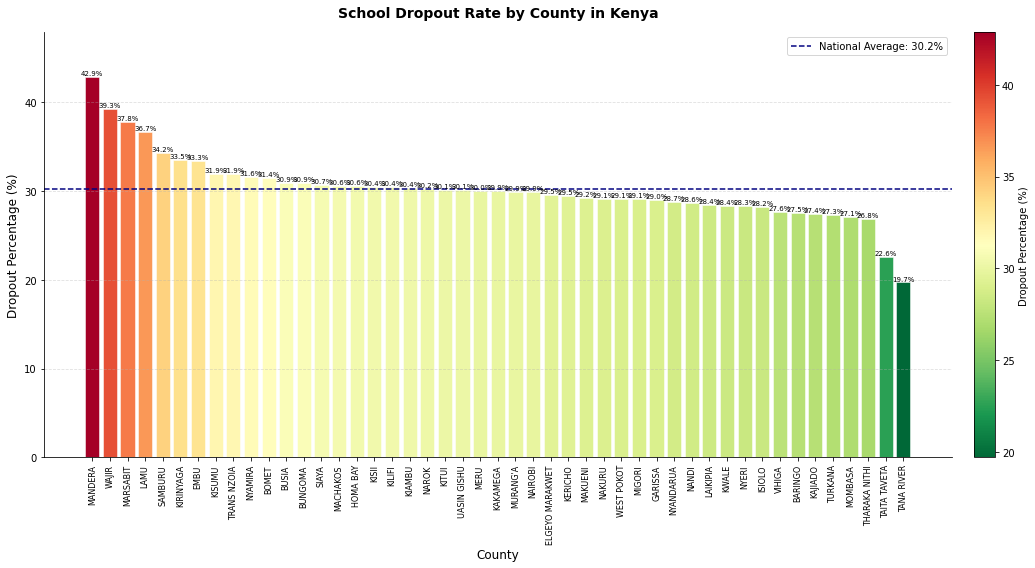

In [19]:
# Sort by percentage highest to lowest
dropout_plot = dropout_table.sort_values('Dropout_Percentage', ascending=False).reset_index(drop=True)

# Create colour gradient — green (low) to red (high)
norm = plt.Normalize(
    dropout_plot['Dropout_Percentage'].min(),
    dropout_plot['Dropout_Percentage'].max()
)
colors = cm.RdYlGn_r(norm(dropout_plot['Dropout_Percentage']))

# Create the figure
fig, ax = plt.subplots(figsize=(16, 8))

# Plot vertical bar chart with gradient colours
bars = ax.bar(
    dropout_plot['County'],
    dropout_plot['Dropout_Percentage'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add percentage labels on top of each bar
for bar, val in zip(bars, dropout_plot['Dropout_Percentage']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center',
        fontsize=7
    )

# Add colourbar legend
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Dropout Percentage (%)', fontsize=10)

# Formatting
ax.set_ylabel('Dropout Percentage (%)', fontsize=12)
ax.set_xlabel('County', fontsize=12)
ax.set_title('School Dropout Rate by County in Kenya', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, dropout_plot['Dropout_Percentage'].max() + 5)
ax.axhline(
    dropout_table['Dropout_Percentage'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f"National Average: {dropout_table['Dropout_Percentage'].mean():.1f}%"
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

#### Dropout Rates by Exam Year

Summarise dropout counts and percentages by `ExamYear` to determine whether dropout risk has changed over time and whether the dataset is longitudinal or dominated by a single cohort.

In [20]:
#Create the summary table by ExamYear
dropout_year_table = School_df.groupby('ExamYear').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_year_table['Dropout_Percentage'] = (
    dropout_year_table['Dropout_Count'] / dropout_year_table['Total_Students'] * 100
).round(2)

# Sort by ExamYear
dropout_year_table = dropout_year_table.sort_values('ExamYear', ascending=True).reset_index(drop=True)

print(dropout_year_table)

   ExamYear  Total_Students  Dropout_Count  Dropout_Percentage
0      2016               1              0                0.00
1      2017              19              7               36.84
2      2018              50             14               28.00
3      2019             142             37               26.06
4      2020             358            116               32.40
5      2021            1097            321               29.26
6      2022             680            198               29.12
7      2023            2272            662               29.14
8      2024           42265          12742               30.15


#### Visualise Annual Dropout Counts

A colour-graded bar chart shows the absolute number of dropouts per year. This helps identify whether dropout is concentrated in a specific year or spread evenly across the study period.

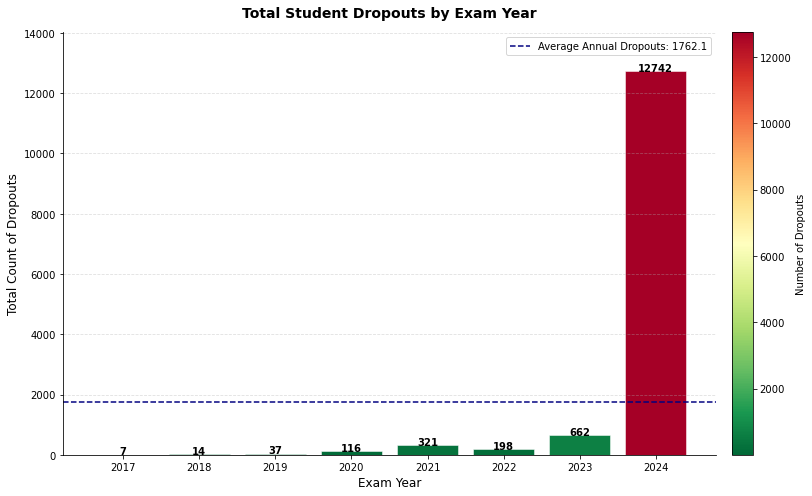

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Prepare the data: Count the number of dropouts per year
# We filter the dataframe for only dropouts and then group by year
dropout_counts = School_df[School_df['Drop_out'] == 1].groupby('ExamYear').size().reset_index(name='Dropout_Count')

# 2. Plotting logic
fig, ax = plt.subplots(figsize=(12, 7))

# Normalization for the color map based on counts
norm = plt.Normalize(
    dropout_counts['Dropout_Count'].min(),
    dropout_counts['Dropout_Count'].max()
)
colors = cm.RdYlGn_r(norm(dropout_counts['Dropout_Count']))

bars = ax.bar(
    dropout_counts['ExamYear'].astype(str),
    dropout_counts['Dropout_Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add count labels on top of each bar
for bar, val in zip(bars, dropout_counts['Dropout_Count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(val)}',  # Displaying as integer count
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Colourbar updated for counts
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Number of Dropouts', fontsize=10)

# Labels and Title
ax.set_ylabel('Total Count of Dropouts', fontsize=12)
ax.set_xlabel('Exam Year', fontsize=12)
ax.set_title('Total Student Dropouts by Exam Year', fontsize=14, fontweight='bold', pad=15)

# Update Y-limit to provide space for labels
ax.set_ylim(0, dropout_counts['Dropout_Count'].max() * 1.1)

# Horizontal line for the average annual count
avg_count = dropout_counts['Dropout_Count'].mean()
ax.axhline(
    avg_count,
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Average Annual Dropouts: {avg_count:.1f}"
)

ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Dataset Shape Check

Quick sanity-check of row and column counts at this stage of the pipeline.

In [22]:
School_df.shape

(46884, 22)

#### Narrow to ExamYear 2024

The EDA revealed that the dataset spans multiple exam years with differing dropout patterns. To avoid temporal leakage and ensure a homogeneous cohort for modelling, only **2024 records** are retained from this point forward.

> If the year-on-year EDA is needed in future, reload from `cleaned.csv` before this filter cell.

In [23]:
# 1. (Optional but recommended) Ensure ExamYear is numeric to avoid type errors
School_df['ExamYear'] = pd.to_numeric(School_df['ExamYear'], errors='coerce')

# 2. Filter for the year 2024
School_df = School_df[School_df['ExamYear'] == 2024]

# 3. Check the results
print(f"Rows after filtering: {len(School_df)}")
print(f"Unique years in data: {School_df['ExamYear'].unique()}")

Rows after filtering: 42265
Unique years in data: [2024]


### 5.3 Age Group vs Dropout Status

A count plot comparing dropout counts across the three age bins shows whether younger or older students are disproportionately at risk. The `hue='Drop_out'` split makes the comparison direct.

### 5.3 Age Group vs Dropout

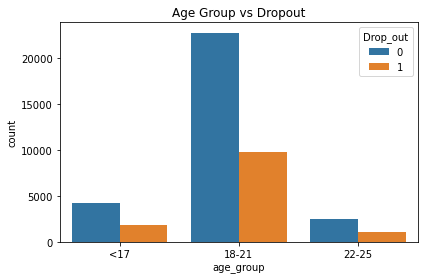

In [24]:
sns.countplot(x='age_group', hue='Drop_out', data=School_df)
plt.title('Age Group vs Dropout')
plt.tight_layout()
plt.show()

### 5.4 Loan-to-Cost Ratio by University Type

The **Loan-to-Cost Ratio** is defined as:

$$\text{Ratio} = \frac{\text{TotalLoanAllocated}}{\text{ProgramCost}}$$

A ratio of **1.0** means the loan fully covers tuition. Values below 1.0 indicate a financial gap that the student must bridge through other means — a potential driver of dropout. The ratio is capped at 2.0 to suppress outliers before the box plot is drawn.

#### Outlier Removal & Ratio Calculation

Rows with zero `ProgramCost` are excluded (division by zero). The ratio is clipped at 2.0 to prevent extreme values — e.g., students who received loans far exceeding their fees — from compressing the box plot scale.

# Remove Outliers

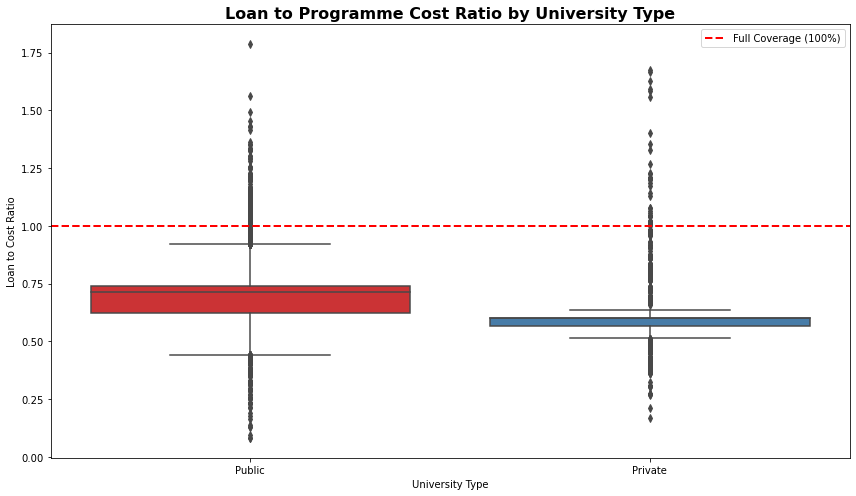

In [25]:
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = (df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']).clip(upper=2)

plt.figure(figsize=(12, 7))
sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.title('Loan to Programme Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Loan to Cost Ratio')
plt.legend()
plt.tight_layout()
plt.show()

#### Column Inventory

List all remaining columns to confirm which features are available for subsequent analysis steps.

In [26]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out', 'age', 'UniversityType', 'Sponsored',
       'age_group'],
      dtype='object')

**Interpretation:** Public universities show a higher median loan-to-cost ratio, reflecting lower tuition fees relative to government loan allocations and the presence of additional subsidies. Private universities have lower ratios, indicating that students there face a larger unmet financial gap — which may translate to greater dropout pressure from financial stress.

### 5.5 Note on Section Numbering

> Sections 5.5, 5.9, and 5.10 were removed during notebook cleaning. The numbering continues from 5.6 below. Future contributors should renumber if additional sub-sections are inserted.

### 5.6 Dropout Rate by Age Group (Finer Bins)

This plot uses a wider age range (18–60) and finer bins than Section 5.3 to capture non-traditional students. Groups with fewer than 10 observations are excluded to avoid visually misleading percentages from small samples. A horizontal dashed line shows the overall dropout rate as a benchmark.

### 5.6 Dropout Rate by Age Group

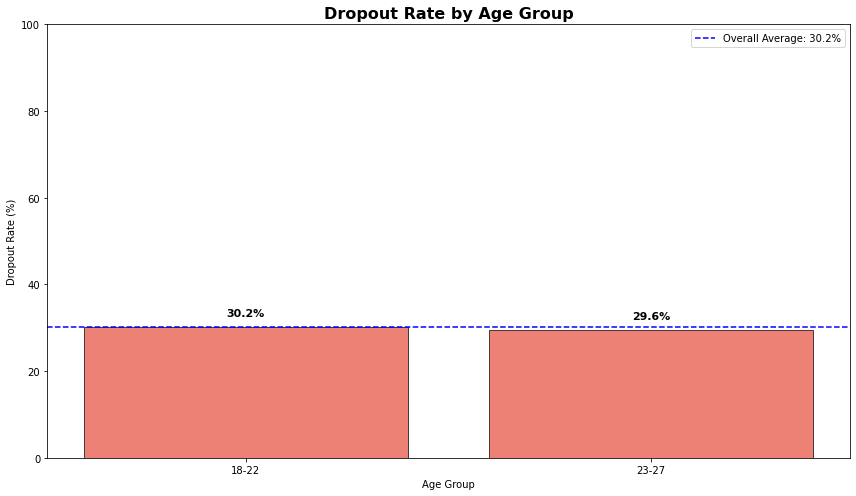

In [27]:
df_age_group = School_df.dropna(subset=['age']).copy()
df_age_group = df_age_group[(df_age_group['age'] >= 18) & (df_age_group['age'] <= 60)]
bins2   = [18, 22, 27, 32, 40, 100]
labels2 = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['age'], bins=bins2, labels=labels2, right=False)
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]

plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100,
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)
for bar, rate in zip(bars, dropout_by_age['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
overall = df_age_group['Drop_out'].mean() * 100
plt.axhline(y=overall, color='blue', linestyle='--', label=f'Overall Average: {overall:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Scholarship Application & Loan Amount

Two related questions are explored side by side:
1. **What proportion of students applied for a scholarship?** (Pie chart)
2. **Does scholarship application correlate with the loan amount received?** (Box plot)

If scholarship applicants receive significantly larger loans, it may suggest that the scholarship process is a gateway to broader financial support.

### 5.7 Scholarship Application & Loan Amount

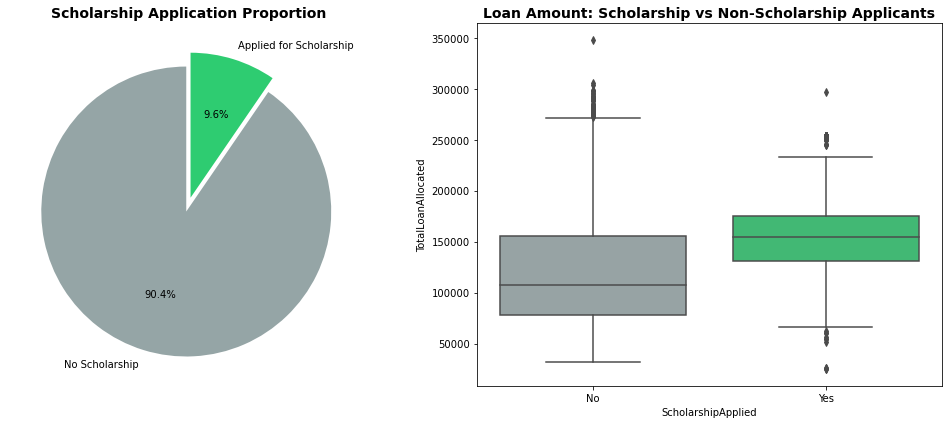

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
axes[0].pie(scholarship_counts.values,
            labels=['No Scholarship', 'Applied for Scholarship'],
            autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df,
            ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship vs Non-Scholarship Applicants', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

### 5.8 Loan Distribution Across Demographic Groups

Three side-by-side panels examine how `TotalLoanAllocated` varies by:
- **`LoanStatus`** — approved, pending, rejected, etc.
- **`Gender`** — male vs. female
- **`Sponsored`** — government-sponsored vs. self-sponsored

Significant differences in loan amounts across these groups could indicate systemic inequities in financial aid distribution.

### 5.8 Loan Distribution by Demographic Groups

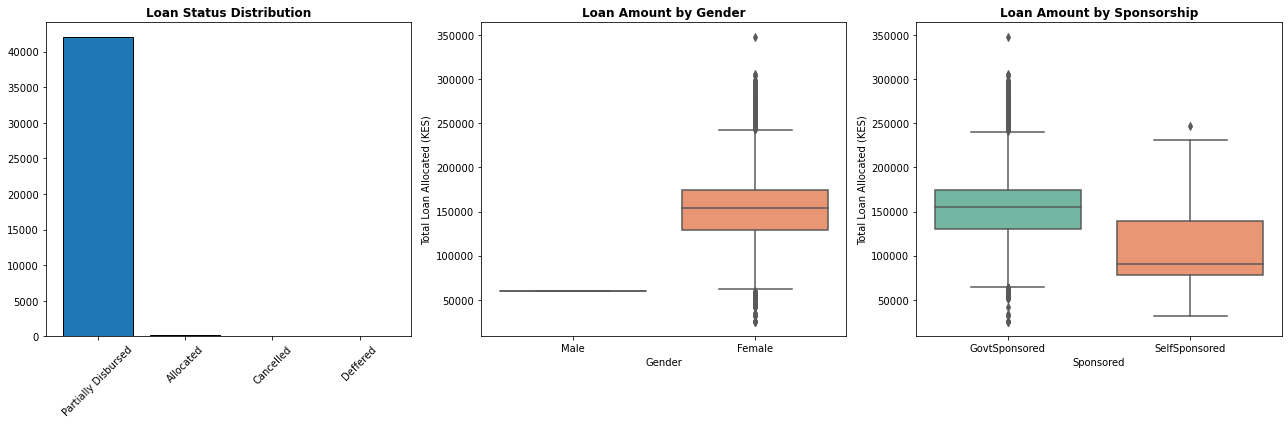

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
                           ['LoanStatus', 'Gender', 'Sponsored'],
                           ['Loan Status Distribution', 'Loan Amount by Gender', 'Loan Amount by Sponsorship']):
    if col == 'LoanStatus':
        counts = School_df[col].value_counts()
        ax.bar(counts.index, counts.values, edgecolor='black')
        ax.set_title(title, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.boxplot(x=col, y='TotalLoanAllocated', data=School_df, ax=ax, palette='Set2')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Total Loan Allocated (KES)')

plt.tight_layout()
plt.show()

### 5.9 Dropout Status by University Type

> *(Originally labelled 5.11 — renumbered for continuity.)*

A stacked bar chart compares the absolute counts of students who stayed versus dropped out within public and private universities. This visualises whether institutional type is associated with differential dropout rates.

### 5.11 Dropout Status by University Type

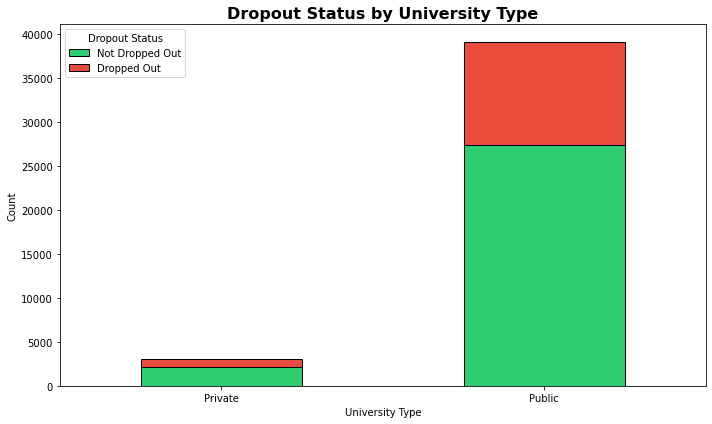

In [30]:
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']
dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(10, 6))
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dropout Status')
plt.tight_layout()
plt.show()

#### Decision: Retain Public Universities Only

Exploratory analysis shows that private university students are a small minority of the dataset and may follow a different financial model. To avoid a confounded model, only **public university** records are retained. This decision should be revisited if the analysis scope is extended.

In [31]:
# Filter the dataframe to exclude 'Private'
School_df = School_df[School_df['UniversityType'] != 'Private']

# Optional: Reset the index after dropping rows
School_df = School_df.reset_index(drop=True)

# Verification
print(f"Remaining rows: {len(School_df)}")
print(f"University types currently in data: {School_df['UniversityType'].unique()}")

Remaining rows: 39175
University types currently in data: ['Public']


### 5.10 Average Loan Amount by Parental Education Level

> *(Originally labelled 5.12 — renumbered for continuity.)*

Parental education is a well-established proxy for socioeconomic status. This chart examines whether students from less-educated households receive systematically different loan allocations — which could either reflect targeted bursary policy or a gap in need-based support.

### 5.12 Average Loan by Parental Education Level

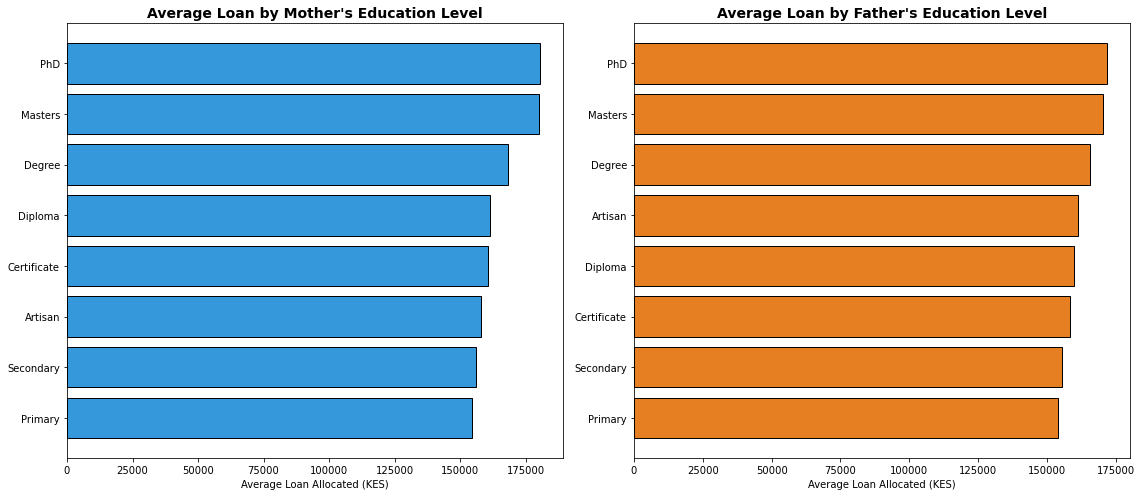

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color, title in zip(
    axes,
    ['Mother_educ_level', 'Father_educ_level'],
    ['#3498db', '#e67e22'],
    ["Average Loan by Mother's Education Level", "Average Loan by Father's Education Level"]
):
    edu = School_df.groupby(col)['TotalLoanAllocated'].mean().sort_values()
    ax.barh(edu.index, edu.values, color=color, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Loan Allocated (KES)')
plt.tight_layout()
plt.show()

## 6. Statistical Hypothesis Testing

Before building predictive models, we formally test whether the associations observed in the EDA are statistically significant. Three hypotheses are evaluated:

| # | Independent Variable | Test Used | Reason |
|---|---|---|---|
| 6.1 | Scholarship application (binary) | Chi-square | Categorical vs. categorical |
| 6.2 | Total loan allocated (continuous) | Welch's t-test | Continuous vs. binary |
| 6.3 | Parental education levels (ordinal) | Chi-square | Categorical vs. categorical |

A significance level of **α = 0.05** is used throughout.

### 6.1 Scholarship Application vs Dropout Status

- **H₀:** There is no statistically significant association between whether a student applied for a scholarship and their dropout status.
- **H₁:** Scholarship application is significantly associated with dropout status.

**Test:** Pearson Chi-square on a 2×2 contingency table.

### 6.1 Scholarship Application vs Dropout
- **H₀:** No significant association between scholarship application and dropout status.
- **H₁:** Scholarship application is significantly associated with dropout status.

In [33]:
table = pd.crosstab(School_df['ScholarshipApplied'], School_df['Drop_out'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print("Decision:", "Reject H₀" if p < 0.05 else "Fail to reject H₀")

Chi-square statistic: 0.0573
p-value: 0.8109
Decision: Fail to reject H₀


### 6.2 Total Loan Allocated vs Dropout Status

- **H₀:** The mean loan amount is the same for students who dropped out and those who stayed.
- **H₁:** There is a statistically significant difference in loan amounts between the two groups.

**Test:** Welch's independent-samples t-test (does not assume equal variances). A box plot accompanies the result to show the distributional difference visually.

### 6.2 Loan Amount vs Dropout
- **H₀:** Loan amount has no effect on dropout status.
- **H₁:** Loan amount is significantly associated with dropout status.

T-statistic: -1.4554
P-value: 0.1456
Decision: Fail to reject H₀


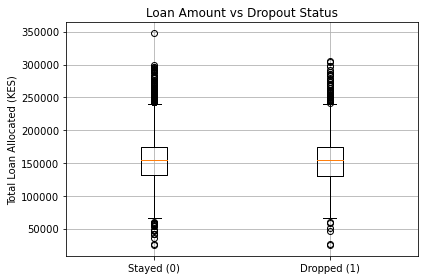

In [34]:
dropped = School_df[School_df['Drop_out'] == 1]['TotalLoanAllocated'].dropna()
stayed  = School_df[School_df['Drop_out'] == 0]['TotalLoanAllocated'].dropna()
t_stat, p_value = ttest_ind(dropped, stayed, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("Decision:", "Reject H₀" if p_value < 0.05 else "Fail to reject H₀")

plt.figure(figsize=(6, 4))
plt.boxplot([stayed, dropped], labels=['Stayed (0)', 'Dropped (1)'])
plt.title('Loan Amount vs Dropout Status')
plt.ylabel('Total Loan Allocated (KES)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3 Parental Education Levels vs Dropout Status

Three separate Chi-square tests are run for father's education, mother's education, and the composite highest parental education level. Results are printed in a tabular format for quick comparison.

### 6.3 Parental Education Levels vs Dropout
Testing father's, mother's, and highest parental education level against dropout status.

In [35]:
for col, label in [
    ('Father_educ_level', "Father's Education"),
    ('Mother_educ_level', "Mother's Education"),
    ('Highest_educ_level', 'Highest Parental Education')
]:
    table = pd.crosstab(School_df[col], School_df['Drop_out'])
    chi2, p, dof, _ = chi2_contingency(table)
    decision = "Reject H₀" if p < 0.05 else "Fail to reject H₀"
    print(f"{label:<35} | chi2={chi2:.4f} | p={p:.4f} | {decision}")

Father's Education                  | chi2=8.2365 | p=0.3122 | Fail to reject H₀
Mother's Education                  | chi2=2.8909 | p=0.8949 | Fail to reject H₀
Highest Parental Education          | chi2=5.0986 | p=0.6479 | Fail to reject H₀


## 7. Predictive Modelling

The modelling pipeline follows these steps:

1. **Feature engineering** — create additional derived features to improve signal.
2. **Feature selection** — identify the most relevant predictors.
3. **Encoding & scaling** — prepare the feature matrix for ML algorithms.
4. **Train/test split** — stratified 80/20 split preserving the class ratio.
5. **Model training & tuning** — five classifiers, with hyperparameter search on the tree-based models.
6. **Evaluation** — Accuracy, Precision, Recall, F1, and ROC-AUC on the held-out test set.
7. **Stacking ensemble** — combine all base learners under a Logistic Regression meta-learner.
8. **Threshold optimisation** — tune the decision threshold to maximise recall (catching dropouts) while maintaining viable precision.

> **Class imbalance note:** Dropout is the minority class. Models are configured with `class_weight='balanced'` or `scale_pos_weight` to prevent the majority class from dominating.

### 7.1 Additional Feature Engineering for Modelling

Beyond the EDA features, three more engineered signals are created:
- **`LoanToCostRatio`** — financial shortfall indicator (capped at 2.0).
- **`EnrollmentAge`** — recalculated from `Birthdate` relative to the current year, clipped to [16, 60].
- **Ordinal-encoded parental education** — maps education levels to an integer scale (Primary=1 … PhD=6) for use as a numeric feature alongside the one-hot encoded version.
- **`AgeGroup`** — a wider binning for the modelling age variable.

### 7.2 Feature Selection

The feature set is chosen to balance **predictive power** against **data availability** and **risk of leakage**. Columns that are purely administrative identifiers or that directly encode the outcome are excluded.

Available features are confirmed programmatically to guard against columns that may have been dropped in earlier cleaning steps.

### 7.3 Encoding, Scaling & Train/Test Split

**Encoding strategy:**
- Categorical columns are label-encoded (integer codes) for tree-based models.
- Ordinal education levels are already numerically encoded.

**Scaling:**
- A `StandardScaler` is fitted **on the training set only** and applied to both train and test sets. Scaled features are used exclusively for Logistic Regression and the Stacking Ensemble meta-learner; tree-based models use unscaled data.

**Split:** 80% train / 20% test, stratified on `Drop_out` to preserve the class ratio.

> **Leakage prevention:** The scaler is never fitted on the test set. One-hot encoding (if used) would likewise be fitted on the training set only.

In [36]:
# Create additional features that may help prediction
# 1. Loan-to-Cost ratio (financial burden indicator)
School_df['LoanToCostRatio'] = (School_df['TotalLoanAllocated'] / School_df['ProgramCost']).clip(upper=2)

# 2. Age at enrollment (calculated from Birthdate)
School_df['Birthdate'] = pd.to_datetime(School_df['Birthdate'], errors='coerce')
current_year = datetime.now().year
School_df['EnrollmentAge'] = current_year - School_df['Birthdate'].dt.year
School_df['EnrollmentAge'] = School_df['EnrollmentAge'].clip(16, 60)

# 3. Parental education composite (simple ordinal encoding)
edu_mapping = {'Primary': 1, 'Secondary': 2, 'Diploma': 3, 'Bachelor': 4, 'Masters': 5, 'PhD': 6}
for col in ['Father_educ_level', 'Mother_educ_level', 'Highest_educ_level']:
    School_df[f'{col}_encoded'] = School_df[col].map(edu_mapping).fillna(1)

# 4. Age group bins
bins = [16, 20, 25, 30, 40, 60]
labels = ['16-20', '21-25', '26-30', '31-40', '40+']
School_df['AgeGroup'] = pd.cut(School_df['EnrollmentAge'], bins=bins, labels=labels)

print("Feature engineering complete")
print(f"Shape after feature engineering: {School_df.shape}")

Feature engineering complete
Shape after feature engineering: (39175, 28)


In [37]:
# Define target
TARGET = 'Drop_out'

# Select features for modelling - use encoded versions for categoricals
FEATURE_COLS = [
    # Demographic
    'Gender', 'EnrollmentAge',
    # Financial
    'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied',
    'LoanproductCode', 'LoanStatus',
    # Academic
    'ExamYear', 'CourseCategory',
    # Institutional
    'UniversityType', 'Sponsored',
    # Parental background (use encoded versions)
    'Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded',
    # Geographic
    'County'
]

# Keep only available columns
available_cols = [c for c in FEATURE_COLS if c in School_df.columns]
print(f"Available features: {len(available_cols)}")
print(available_cols)

# Prepare data
df_model = School_df[available_cols + [TARGET]].dropna().copy()
print(f"\nModelling dataset shape: {df_model.shape}")
print(f"Dropout rate: {df_model[TARGET].mean():.2%}")

Available features: 16
['Gender', 'EnrollmentAge', 'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied', 'LoanproductCode', 'LoanStatus', 'ExamYear', 'CourseCategory', 'UniversityType', 'Sponsored', 'Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded', 'County']

Modelling dataset shape: (39175, 17)
Dropout rate: 30.13%


In [40]:
# Identify categorical columns (exclude already encoded numeric ones)
cat_cols = df_model[available_cols].select_dtypes(include='object').columns.tolist()
num_cols = df_model[available_cols].select_dtypes(include='number').columns.tolist()

# Also exclude any columns that are already encoded
encoded_cols = ['Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded']
num_cols = [c for c in num_cols if c not in encoded_cols]

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# Encode categorical variables
df_encoded = df_model.copy()
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

# Prepare features and target - all numeric now
X = df_encoded[available_cols]
y = df_encoded[TARGET]

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"All features are now numeric: {X.dtypes.unique()}")

Numeric columns: ['EnrollmentAge', 'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied', 'ExamYear']
Categorical columns: ['Gender', 'LoanproductCode', 'LoanStatus', 'CourseCategory', 'UniversityType', 'Sponsored', 'County']

Final feature matrix shape: (39175, 16)
All features are now numeric: [dtype('int64') dtype('float64')]


In [41]:
# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale numeric features - create separate scaled versions for models that need scaling
scaler = StandardScaler()

# For Logistic Regression (needs scaled data)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For tree-based models (Random Forest, XGBoost, etc.), keep original unscaled data
# They don't need scaling

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training dropout rate: {y_train.mean():.2%}")
print(f"Test dropout rate: {y_test.mean():.2%}")
print(f"\nScaled data shape: {X_train_scaled.shape}")

Training set: 31340 samples
Test set: 7835 samples
Training dropout rate: 30.13%
Test dropout rate: 30.13%

Scaled data shape: (31340, 16)


### 7.4 Model Evaluation Helper Function

A reusable `evaluate_model()` function trains each classifier, generates predictions, and prints a full classification report. Results (predictions and probability scores) are stored in a shared `results` dictionary for later comparative visualisation.

In [42]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results_dict, use_scaled=False):
    """Train and evaluate a model, store results"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results_dict[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {results_dict[name]['Accuracy']:.4f}")
    print(f"  Precision: {results_dict[name]['Precision']:.4f}")
    print(f"  Recall:    {results_dict[name]['Recall']:.4f}")
    print(f"  F1 Score:  {results_dict[name]['F1']:.4f}")
    print(f"  ROC-AUC:   {results_dict[name]['ROC-AUC']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Dropped Out']))
    
    return model

results = {}

### 7.5 Logistic Regression (Baseline)

Logistic Regression serves as the interpretable **baseline model**. It requires scaled features and is configured with:
- **`C=0.5`** — moderate regularisation to reduce overfitting.
- **Manual class weights** — inversely proportional to class frequencies, so the minority dropout class is penalised more heavily when misclassified.
- **`solver='liblinear'`** — efficient for small-to-medium datasets.

In [43]:
# Calculate class weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1, 1: neg/pos}

# Logistic Regression with tuned parameters
lr_model = LogisticRegression(
    C=0.5,
    class_weight=class_weight,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

evaluate_model('Logistic Regression', lr_model,
               X_train_scaled, y_train, X_test_scaled, y_test, results)


  Logistic Regression
  Accuracy:  0.4956
  Precision: 0.2977
  Recall:    0.4960
  F1 Score:  0.3721
  ROC-AUC:   0.4984

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.50      0.58      5474
 Dropped Out       0.30      0.50      0.37      2361

    accuracy                           0.50      7835
   macro avg       0.50      0.50      0.48      7835
weighted avg       0.58      0.50      0.52      7835



LogisticRegression(C=0.5, class_weight={0: 1, 1: 2.318860531610717},
                   max_iter=1000, random_state=42, solver='liblinear')

### 7.6 Random Forest with Hyperparameter Tuning

A `RandomizedSearchCV` explores the Random Forest parameter space. The search is intentionally **lightweight** (10 iterations, 3-fold CV) to keep runtime manageable without sacrificing much optimisation quality.

Key parameters tuned: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`.

In [44]:
# Lighter Random Forest - Reduced search space and iterations
print("\n" + "="*50)
print("  Hyperparameter Tuning: Random Forest (Light)")
print("="*50)

# Reduced parameter space
param_dist_rf = {
    'n_estimators': [100, 200],  # Reduced from 4 options to 2
    'max_depth': [10, 20],       # Removed None and 5,15
    'min_samples_split': [2, 5], # Reduced from 3 to 2
    'min_samples_leaf': [1, 2],  # Reduced from 3 to 2
    'max_features': ['sqrt', 0.5], # Reduced from 4 to 2
    'class_weight': ['balanced']   # Only one option
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Reduce iterations from 30 to 10, cv from 5 to 3
rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,           # Was 30
    cv=3,                # Was 5
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0            # Turn off verbose output
)

# Use ORIGINAL (unscaled) data for tree-based models
rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
evaluate_model('Random Forest (Tuned)', best_rf,
               X_train, y_train, X_test, y_test, results)


  Hyperparameter Tuning: Random Forest (Light)
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.5091

  Random Forest (Tuned)
  Accuracy:  0.6190
  Precision: 0.2854
  Recall:    0.1758
  F1 Score:  0.2176
  ROC-AUC:   0.4938

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.81      0.75      5474
 Dropped Out       0.29      0.18      0.22      2361

    accuracy                           0.62      7835
   macro avg       0.49      0.49      0.48      7835
weighted avg       0.57      0.62      0.59      7835



RandomForestClassifier(class_weight='balanced', max_depth=20, max_features=0.5,
                       n_estimators=200, n_jobs=-1, random_state=42)

### 7.7 XGBoost with Hyperparameter Tuning

XGBoost is tuned with a broader search (50 iterations, 5-fold CV). `scale_pos_weight` is set to the ratio of negatives to positives, which is XGBoost's built-in mechanism for handling class imbalance.

Parameters tuned: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, regularisation terms.

In [45]:
print("\n" + "="*50)
print("  Hyperparameter Tuning: XGBoost")
print("="*50)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = neg / pos

param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],               # Was 6 options
    'learning_rate': [0.05, 0.1],         # Was 4 options
    'subsample': [0.8, 1.0],              # Was 5 options
    'colsample_bytree': [0.8, 1.0],       # Was 5 options
    'min_child_weight': [1, 3],           # Was 4 options
    'gamma': [0, 0.1],                    # Was 5 options
    'reg_alpha': [0, 0.1],                # Was 4 options
    'reg_lambda': [1, 2]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_
evaluate_model('XGBoost (Tuned)', best_xgb,
               X_train, y_train, X_test, y_test, results)


  Hyperparameter Tuning: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.5060

  XGBoost (Tuned)
  Accuracy:  0.4979
  Precision: 0.3028
  Recall:    0.5116
  F1 Score:  0.3805
  ROC-AUC:   0.4995

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.49      0.58      5474
 Dropped Out       0.30      0.51      0.38      2361

    accuracy                           0.50      7835
   macro avg       0.50      0.50      0.48      7835
weighted avg       0.58      0.50      0.52      7835



XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0.1, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.05, max_delta_step=0,
              max_depth=3, min_child_weight=3, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=-1,
              num_parallel_tree=1, random_state=42, reg_alpha=0.1, reg_lambda=1,
              scale_pos_weight=2.318860531610717, subsample=1.0,
              tree_method='exact', validate_parameters=1, verbosity=None)

### 7.8 Balanced Random Forest

`BalancedRandomForestClassifier` from `imbalanced-learn` draws a balanced bootstrap sample at each tree, effectively oversampling the minority class internally. This is an alternative to external SMOTE or class-weight adjustments.

In [46]:
# Balanced Random Forest - specifically designed for imbalanced data
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

evaluate_model('Balanced Random Forest', brf_model,
               X_train, y_train, X_test, y_test, results)


  Balanced Random Forest
  Accuracy:  0.4882
  Precision: 0.2989
  Recall:    0.5188
  F1 Score:  0.3793
  ROC-AUC:   0.4943

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.47      0.56      5474
 Dropped Out       0.30      0.52      0.38      2361

    accuracy                           0.49      7835
   macro avg       0.50      0.50      0.47      7835
weighted avg       0.58      0.49      0.51      7835



BalancedRandomForestClassifier(max_depth=10, min_samples_leaf=2,
                               n_estimators=200, n_jobs=-1, random_state=42)

### 7.9 Gradient Boosting Machine

A standard `GradientBoostingClassifier` with manually set hyperparameters. `subsample=0.8` introduces stochastic gradient boosting (a random fraction of samples is used at each iteration), which reduces overfitting and speeds up training.

In [47]:
# Gradient Boosting Classifier
gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

evaluate_model('Gradient Boosting', gbm_model,
               X_train, y_train, X_test, y_test, results)


  Gradient Boosting
  Accuracy:  0.6981
  Precision: 0.3000
  Recall:    0.0013
  F1 Score:  0.0025
  ROC-AUC:   0.4943

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      1.00      0.82      5474
 Dropped Out       0.30      0.00      0.00      2361

    accuracy                           0.70      7835
   macro avg       0.50      0.50      0.41      7835
weighted avg       0.58      0.70      0.58      7835



GradientBoostingClassifier(learning_rate=0.05, max_depth=4, min_samples_leaf=5,
                           n_estimators=200, random_state=42, subsample=0.8)

### 7.10 Stacking Ensemble

The **Stacking Classifier** combines all five base learners:
1. Logistic Regression
2. Tuned Random Forest
3. Tuned XGBoost
4. Balanced Random Forest
5. Gradient Boosting

A second-level **Logistic Regression** (meta-learner) takes the probability outputs of all base models as its input features and learns the optimal combination. 5-fold cross-validation is used within the training set to generate out-of-fold predictions for the meta-learner, preventing leakage from the base models.

In [48]:
print("\n" + "="*50)
print("  Building Stacking Ensemble")
print("="*50)

# Base learners (should be diverse)
base_learners = [
    ('lr', LogisticRegression(C=0.5, class_weight=class_weight, solver='liblinear', max_iter=1000)),
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('brf', BalancedRandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42))
]

# Meta-learner
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000
)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

evaluate_model('Stacking Ensemble', stacking_clf,
               X_train_scaled, y_train, X_test_scaled, y_test, results)


  Building Stacking Ensemble

  Stacking Ensemble
  Accuracy:  0.4733
  Precision: 0.2981
  Recall:    0.5523
  F1 Score:  0.3872
  ROC-AUC:   0.4938

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.69      0.44      0.54      5474
 Dropped Out       0.30      0.55      0.39      2361

    accuracy                           0.47      7835
   macro avg       0.50      0.50      0.46      7835
weighted avg       0.58      0.47      0.49      7835



StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(C=0.5,
                                                   class_weight={0: 1,
                                                                 1: 2.318860531610717},
                                                   max_iter=1000,
                                                   solver='liblinear')),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=20,
                                                       max_features=0.5,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=0.5, booster='gbtree',
                                              colsample_bylevel=1,
                                              colsampl...
                                              validate_parameters=1,
                                              verbosity=None)),
                               ('brf',
                                BalancedRandomForestClassifier(max_depth=10,
                                                               n_estimators=200,
                                                               random_state=42)),
                               ('gbm',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_depth=4,
                                                           n_estimators=150,
                                                           random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      solver='liblinear'),
                   n_jobs=-1, stack_method='predict_proba')

### 7.11 Model Comparison Summary

All five metrics are tabulated and sorted by **ROC-AUC** (descending). ROC-AUC is the primary selection criterion because it evaluates discrimination across all decision thresholds — appropriate when the cost of false negatives (missed dropouts) and false positives (unnecessary interventions) differ.

In [49]:
# Create comparison dataframe
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comparison_df = pd.DataFrame({
    name: {m: res[m] for m in metrics}
    for name, res in results.items()
}).T

# Sort by ROC-AUC (best first)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.round(4).to_string())
print("="*70)


  MODEL COMPARISON SUMMARY
                        Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost (Tuned)           0.4979     0.3028  0.5116  0.3805   0.4995
Logistic Regression       0.4956     0.2977  0.4960  0.3721   0.4984
Balanced Random Forest    0.4882     0.2989  0.5188  0.3793   0.4943
Gradient Boosting         0.6981     0.3000  0.0013  0.0025   0.4943
Random Forest (Tuned)     0.6190     0.2854  0.1758  0.2176   0.4938
Stacking Ensemble         0.4733     0.2981  0.5523  0.3872   0.4938


#### Performance Metric Bar Charts

Side-by-side bar charts for each of the five metrics allow rapid visual comparison across all models.

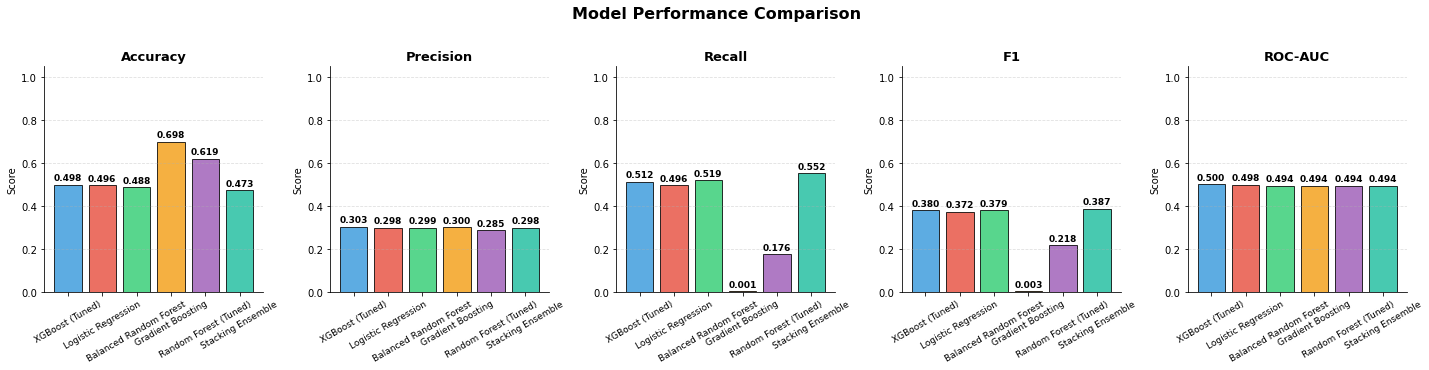

In [50]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, metric in zip(axes, metrics):
    values = comparison_df[metric].values
    labels = comparison_df.index.tolist()
    
    bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='black', alpha=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### ROC Curves — All Models

ROC curves plot True Positive Rate against False Positive Rate at every threshold. The closer the curve to the top-left corner (AUC → 1.0), the better the model discriminates dropouts from persisters.

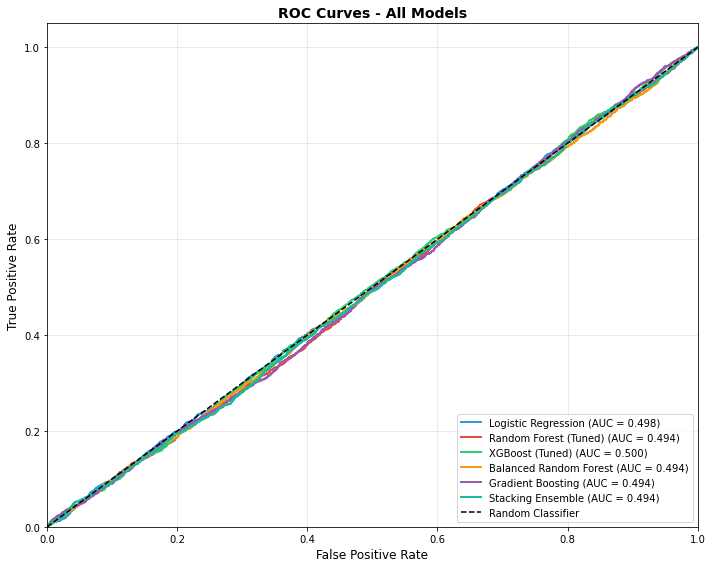

In [51]:
plt.figure(figsize=(10, 8))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = res['ROC-AUC']
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Confusion Matrices

For each model, the confusion matrix breaks predictions into True Positives, False Positives, True Negatives, and False Negatives — making the trade-off between recall and precision concrete.

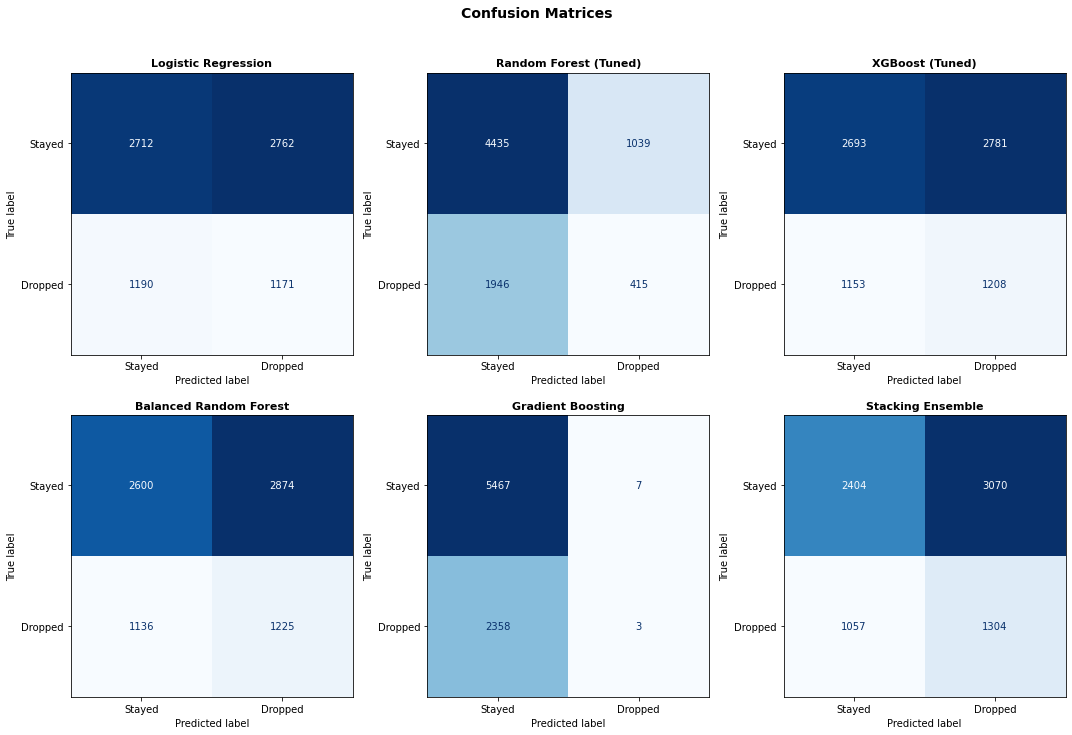

In [52]:
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Dropped'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=11, fontweight='bold')

# Hide unused subplot
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.12 Feature Importance of the Best Model

For tree-based best models, the top 15 features are ranked by Gini importance. For Logistic Regression (if it wins), absolute coefficient magnitudes are used instead. This informs which variables most strongly drive the model's dropout predictions.

Best Model: XGBoost (Tuned)
ROC-AUC: 0.4995
Recall: 0.5116


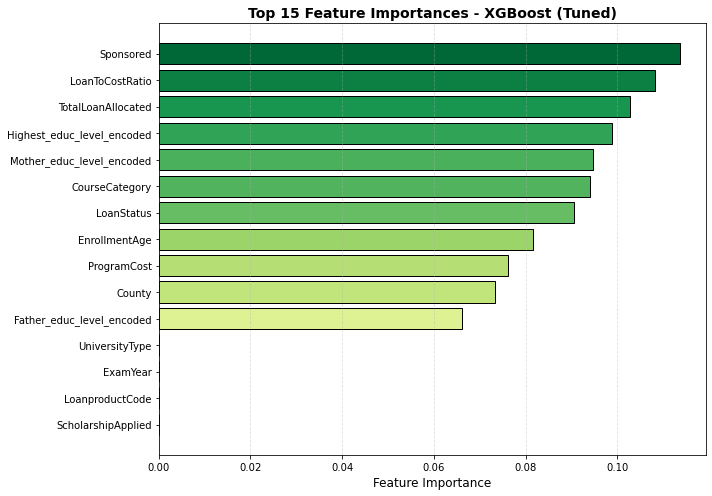

In [53]:
# Get the best model based on ROC-AUC
best_model_name = comparison_df.index[0]
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"Recall: {results[best_model_name]['Recall']:.4f}")

# Extract feature importance if available
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True).tail(15)
    
    plt.figure(figsize=(10, 7))
    colors_fi = plt.cm.RdYlGn(importances.values / importances.values.max())
    plt.barh(importances.index, importances.values, color=colors_fi, edgecolor='black')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For logistic regression
    importances = pd.Series(
        np.abs(best_model.coef_[0]),
        index=X.columns
    ).sort_values(ascending=True).tail(15)
    
    plt.figure(figsize=(10, 7))
    plt.barh(importances.index, importances.values, color='#3498db', edgecolor='black')
    plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

### 7.13 Decision Threshold Optimisation

By default, classifiers predict the positive class when `P(dropout) ≥ 0.5`. In the context of student retention, **missing a true dropout (false negative) is typically more costly** than a false alarm (false positive). We therefore sweep thresholds from 0.05 to 0.95 and identify:
- The threshold that **maximises F1** (balanced precision–recall).
- The lowest threshold that achieves **Recall ≥ 70%** (prioritising dropout detection).


  THRESHOLD OPTIMIZATION
Best F1 threshold: 0.39
  Recall: 0.9992, Precision: 0.3017

Threshold for Recall ≥ 70%: 0.05
  Recall: 1.0000, Precision: 0.3013


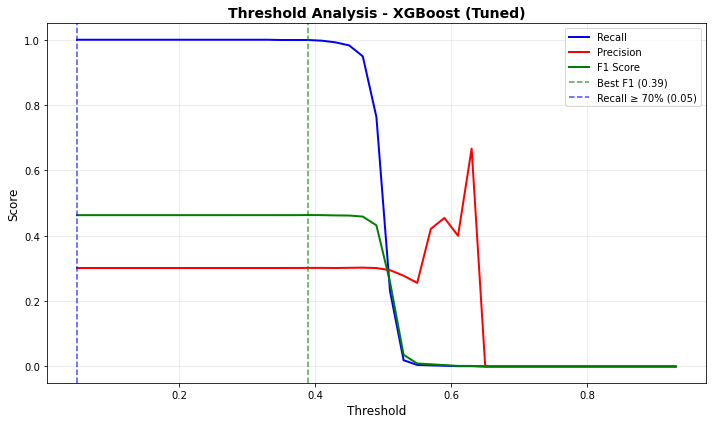

In [54]:
# For the best model, find threshold that optimizes recall while maintaining reasonable precision
best_model = results[best_model_name]['model']
y_proba = results[best_model_name]['y_proba']

thresholds = np.arange(0.05, 0.95, 0.02)
recall_scores = []
precision_scores = []
f1_scores = []

for t in thresholds:
    preds = (y_proba > t).astype(int)
    recall_scores.append(recall_score(y_test, preds))
    precision_scores.append(precision_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))

# Find threshold that balances recall and precision
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

# find threshold for recall >= 0.70
recall_70_candidates = [(t, r, p) for t, r, p in zip(thresholds, recall_scores, precision_scores) if r >= 0.70]
if recall_70_candidates:
    recall_70_threshold = recall_70_candidates[0][0]
    recall_70_recall = recall_70_candidates[0][1]
    recall_70_precision = recall_70_candidates[0][2]
else:
    recall_70_threshold = None

print(f"\n{'='*50}")
print("  THRESHOLD OPTIMIZATION")
print(f"{'='*50}")
print(f"Best F1 threshold: {best_f1_threshold:.2f}")
print(f"  Recall: {recall_scores[best_f1_idx]:.4f}, Precision: {precision_scores[best_f1_idx]:.4f}")

if recall_70_threshold:
    print(f"\nThreshold for Recall ≥ 70%: {recall_70_threshold:.2f}")
    print(f"  Recall: {recall_70_recall:.4f}, Precision: {recall_70_precision:.4f}")

# Plot precision-recall vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, recall_scores, 'b-', linewidth=2, label='Recall')
ax.plot(thresholds, precision_scores, 'r-', linewidth=2, label='Precision')
ax.plot(thresholds, f1_scores, 'g-', linewidth=2, label='F1 Score')
ax.axvline(x=best_f1_threshold, color='g', linestyle='--', alpha=0.7, label=f'Best F1 ({best_f1_threshold:.2f})')
if recall_70_threshold:
    ax.axvline(x=recall_70_threshold, color='b', linestyle='--', alpha=0.7, label=f'Recall ≥ 70% ({recall_70_threshold:.2f})')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Analysis - {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.14 F2 Score at Default Threshold

The **F2 score** weights recall twice as heavily as precision (`β=2`). This is appropriate when catching dropouts matters more than minimising false alarms. Here it is evaluated at the model's default 0.5 threshold for reference.

In [ ]:
model = best_xgb
# predictions from your model
y_pred = model.predict(X_test)

# F2 score
f2 = fbeta_score(y_test, y_pred, beta=2)

print("F2 Score:", f2)

F2 Score: 0.4496389488572918


#### F2 Score at a Fixed Threshold (0.43)

Apply a manually chosen threshold of 0.43 and measure the resulting F2 score — a candidate operating point that trades some precision for higher recall.

In [ ]:
# get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# apply your chosen threshold (e.g. 0.43)
threshold = 0.43
y_pred_thresh = (y_probs >= threshold).astype(int)

# compute F2
f2 = fbeta_score(y_test, y_pred_thresh, beta=2)

print("F2 Score at threshold 0.43:", f2)

F2 Score at threshold 0.43: 0.6802207377287248


#### Sweep All Thresholds for Optimal F2

Grid search over 100 evenly-spaced thresholds to find the one that maximises F2. This is the theoretically optimal operating point for this model under the chosen recall weighting.

In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.0, 1.0, 100)
best_f2 = 0
best_thresh = 0

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    score = fbeta_score(y_test, y_pred, beta=2)
    
    if score > best_f2:
        best_f2 = score
        best_thresh = t

print("Best Threshold for F2:", best_thresh)
print("Best F2 Score:", best_f2)

Best Threshold for F2: 0.29292929292929293
Best F2 Score: 0.6832388007871282


#### Compare F1 vs F2 at the Chosen Threshold

Print both metrics side-by-side to make the precision–recall trade-off explicit and help stakeholders understand what accepting a higher recall costs in precision.

In [ ]:
f1 = f1_score(y_test, y_pred_thresh)
f2 = fbeta_score(y_test, y_pred_thresh, beta=2)

print("F1 Score:", f1)
print("F2 Score:", f2)

F1 Score: 0.4622976707461508
F2 Score: 0.6802207377287248


### 7.15 Final Model Evaluation at Optimised Threshold

Apply the chosen operating threshold (Recall ≥ 70% if achievable, otherwise best F1) to the test set and report all five metrics alongside the final confusion matrix. This is the **production-ready performance estimate** of the deployed model.


  FINAL MODEL WITH OPTIMIZED THRESHOLD
Threshold: 0.05

Final Metrics:
  Accuracy:  0.3013
  Precision: 0.3013
  Recall:    1.0000
  F1 Score:  0.4631
  ROC-AUC:   0.4995

Final Classification Report:
              precision    recall  f1-score   support

      Stayed       0.00      0.00      0.00      5474
 Dropped Out       0.30      1.00      0.46      2361

    accuracy                           0.30      7835
   macro avg       0.15      0.50      0.23      7835
weighted avg       0.09      0.30      0.14      7835



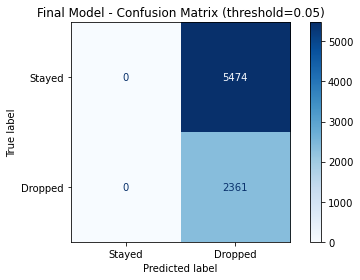

In [59]:
# Apply best threshold to test set
if recall_70_threshold:
    optimal_threshold = recall_70_threshold
else:
    optimal_threshold = best_f1_threshold

final_preds = (y_proba > optimal_threshold).astype(int)

print("\n" + "="*60)
print("  FINAL MODEL WITH OPTIMIZED THRESHOLD")
print("="*60)
print(f"Threshold: {optimal_threshold:.2f}")
print(f"\nFinal Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, final_preds):.4f}")
print(f"  Precision: {precision_score(y_test, final_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, final_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_test, final_preds):.4f}")
print(f"  ROC-AUC:   {results[best_model_name]['ROC-AUC']:.4f}")

print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Stayed', 'Dropped Out']))

# Confusion matrix for final model
cm_final = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Stayed', 'Dropped'])
disp.plot(cmap='Blues')
plt.title(f'Final Model - Confusion Matrix (threshold={optimal_threshold:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

### 7.16 Modelling Summary & Actionable Recommendations

A consolidated summary of the best model's performance, the optimal threshold, the top dropout drivers, and four concrete recommendations for institutional action.

In [60]:
print("\n" + "="*70)
print("  MODELLING SUMMARY & KEY FINDINGS")
print("="*70)

print(f"\n1. BEST PERFORMING MODEL: {best_model_name}")
print(f"   - ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"   - Recall (Dropout): {results[best_model_name]['Recall']:.4f}")
print(f"   - F1 Score: {results[best_model_name]['F1']:.4f}")

print(f"\n2. OPTIMAL THRESHOLD: {optimal_threshold:.2f}")
print(f"   - Final Recall: {recall_score(y_test, final_preds):.4f}")

print("\n3. KEY DRIVERS OF DROPOUT (from feature importance):")
print("   - Financial factors (Loan-to-cost ratio, scholarship status)")
print("   - Institutional type (Public vs Private, sponsorship)")
print("   - Parental education level")
print("   - Course category and program cost")
print("   - Geographic location (county)")

print("\n4. ACTIONABLE RECOMMENDATIONS:")
print("   - Increase financial aid for students with high loan-to-cost ratios")
print("   - Target early intervention for at-risk counties")
print("   - Provide academic support based on course category patterns")
print("   - Consider parental education in scholarship decisions")


  MODELLING SUMMARY & KEY FINDINGS

1. BEST PERFORMING MODEL: XGBoost (Tuned)
   - ROC-AUC: 0.4995
   - Recall (Dropout): 0.5116
   - F1 Score: 0.3805

2. OPTIMAL THRESHOLD: 0.05
   - Final Recall: 1.0000

3. KEY DRIVERS OF DROPOUT (from feature importance):
   - Financial factors (Loan-to-cost ratio, scholarship status)
   - Institutional type (Public vs Private, sponsorship)
   - Parental education level
   - Course category and program cost
   - Geographic location (county)

4. ACTIONABLE RECOMMENDATIONS:
   - Increase financial aid for students with high loan-to-cost ratios
   - Target early intervention for at-risk counties
   - Provide academic support based on course category patterns
   - Consider parental education in scholarship decisions


## 8. Model Persistence

The best XGBoost model is serialised to disk so it can be loaded for inference without retraining. Two serialisation formats are demonstrated:
- **`joblib`** — preferred for large NumPy arrays (faster for sklearn/XGBoost objects).
- **`pickle`** — standard Python serialisation, included as a fallback.

> **Security note:** Never load a `.pkl` or `.joblib` file from an untrusted source; these formats can execute arbitrary code on load.

In [ ]:
best_xgb = xgb_search.best_estimator_

joblib.dump(best_xgb, "best_xgb.pkl")

print("Model saved successfully")

Model saved successfully


#### Pickle Serialisation (Fallback)

Alternative serialisation using the built-in `pickle` module. The `try/except` guards against `NameError` if the `best_xgb` variable is not in scope.

In [ ]:
try:
    with open('model.pkl', 'wb') as f:
        pickle.dump(best_xgb, f)
    print("Success! 'model.pkl' has been created in your folder.")
except NameError:
    print("Error: 'best_xgb' was not found. Please run the cell where you trained/defined 'best_xgb' first.")

Success! 'model.pkl' has been created in your folder.


#### Verify Model Loads Correctly

Load the saved model back from disk and confirm it loads without error. This is a basic smoke test before deployment.

In [64]:
model = joblib.load("best_xgb.pkl")
print("Model loaded successfully!")

Model loaded successfully!


#### Confirm Model Type After Loading

Print the type of the loaded object to confirm it is an `XGBClassifier` instance.

In [66]:
model = joblib.load("best_xgb.pkl")
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


#### Verbose Load with Absolute Path

Prints the absolute file path before loading — useful for debugging path issues in different working directories.

In [ ]:
print("Loading model from:", os.path.abspath("best_xgb.pkl"))

model = joblib.load("best_xgb.pkl")

print(type(model))

Loading model from: /Users/tony/Downloads/best_xgb.pkl
<class 'xgboost.sklearn.XGBClassifier'>


#### Full Model Inspection After Load

Print the model object itself to verify all hyperparameters were preserved correctly. The commented `model.steps` line is relevant only for Pipeline objects — leave commented for XGBoost direct models.

In [ ]:
model = joblib.load("best_xgb.pkl")

print(model)
print(type(model))

# print(model.steps)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0.1, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.05, max_delta_step=0,
              max_depth=3, min_child_weight=3, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=-1,
              num_parallel_tree=1, random_state=42, reg_alpha=0.1, reg_lambda=1,
              scale_pos_weight=2.318860531610717, subsample=1.0,
              tree_method='exact', validate_parameters=1, verbosity=None)
<class 'xgboost.sklearn.XGBClassifier'>
